In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

#PROJECT_ROOT = Path.cwd()
#if not (PROJECT_ROOT / "scripts").is_dir():
#    raise RuntimeError("Start Jupyter from the Gresse repository root.")
#sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

from plot_geo_churn import (
    latest_result_dir,
    load_experiment_data,
    system_latency_dataframe,
    topology_change_dataframe,
    request_latency_dataframe,
    ExperimentData,
)

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def paper_figure(width=7.16, height=3.0):
    """Create a two-column, paper-ready Matplotlib figure in inches."""
    return plt.figure(figsize=(width, height), constrained_layout=True)


In [6]:
# Replace this with a specific completed run when preparing the paper.
# RESULT_DIR = latest_result_dir("../results/geo_churn/")
RESULT_DIR = "../results/geo_churn/geo-churn-20260901T092617Z-88139d1e"

data: ExperimentData = load_experiment_data(RESULT_DIR)
system_latencies = system_latency_dataframe(data)
#topology_changes = topology_change_dataframe(data)
request_latencies = request_latency_dataframe(data.events)

print(f"Loaded {RESULT_DIR}")
display(system_latencies.groupby("latency_type").size().rename("samples"))


/Users/adam/Dev/Gresse/notebooks/plot_geo_churn.py:78: DtypeWarning: Columns (0: detail) have mixed types. Specify dtype option on import or set low_memory=False.
  frame = pd.read_csv(path)


Loaded ../results/geo_churn/geo-churn-20260901T092617Z-88139d1e


latency_type
GC round                      19
P2P pull to delta merge    74950
Replica initialization       112
Replica recovery              87
Name: samples, dtype: int64

GC round
Replica initialization
Replica recovery


/var/folders/tz/fvx5t98176g0bbx35x9zpjdr0000gn/T/ipykernel_91330/3328452821.py:75: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


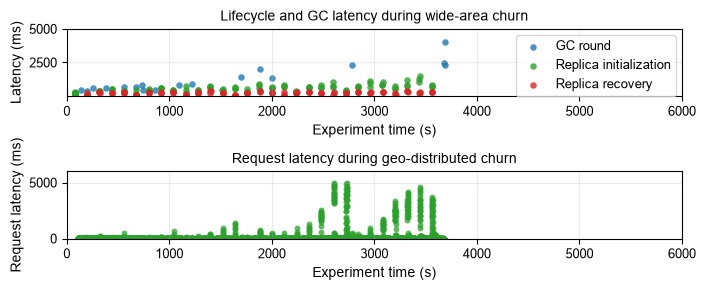

In [9]:
fig = paper_figure()
XLIM_LOW = 0
XLIM_HIGH = 6000

def scatter_system_latencies(
    axis,
    dataframe: pd.DataFrame
) -> plt.Axes:
    """Plot system-operation latencies and topology-change initiation markers."""
    
    colors = plt.get_cmap("tab10")
    for index, (kind, group) in enumerate(dataframe.groupby("latency_type", sort=True)):
        if kind == "P2P pull to delta merge":
            continue;
        axis.scatter(group["experiment_time_s"], group["latency_ms"], label=kind,
                     color=colors(index % 10), alpha=0.8, s=22, linewidths=0)
        print(kind)
    change_colors = {"crash": "#d62728", "graceful_stop": "#9467bd", "spawn": "#2ca02c"}
    #for _, change in topology_changes.iterrows():
    #    action = change["action"]
    #    axis.axvline(change["experiment_time_s"], color=change_colors.get(action, "#555555"),
    #                 linestyle="--", linewidth=1.1, alpha=0.75, label=f"topology: {action}")
    handles, labels = axis.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    axis.set_title("System-operation latency during geo-distributed churn")
    # axis.set_xlabel("Experiment time (s)")
    axis.set_ylabel("Latency (ms)")
    axis.set_xlim(XLIM_LOW, XLIM_HIGH)
    axis.set_ylim(1,5000)
    # axis.set_yscale("log")
    axis.grid(True, which="both", alpha=0.25)
    if unique:
        axis.legend(unique.values(), unique.keys(), loc="best")
    axis.set_title("Lifecycle and GC latency during wide-area churn")
    axis.set_xlabel("Experiment time (s)")
    axis.set_ylabel("Latency (ms)")
    return axis

axis = fig.add_subplot(2, 1, 1)
scatter_system_latencies(axis, system_latencies)

def scatter_latency(
    axis,
    dataframe: pd.DataFrame,
    *,
    title: str = "Request latency during geo-distributed churn",
) -> plt.Axes:
    """Scatter request latency over experiment time, grouped into a legend."""
    if dataframe.empty:
        axis.set_title(title)
        axis.set_xlabel("Experiment time (s)")
        axis.set_ylabel("Request latency (ms)")
        return axis

    colors = plt.get_cmap("tab10")
    for index, (kind, group) in enumerate(dataframe.groupby("latency_type", sort=True)):
        if kind == "replica: client mutation":
            axis.scatter(
                group["experiment_time_s"], group["latency_ms"],
                label=kind, color=colors(index % 10), alpha=0.75, s=18, linewidths=0,
            )
    axis.set_title(title)
    axis.set_xlabel("Experiment time (s)")
    axis.set_ylabel("Request latency (ms)")
    axis.set_xlim(XLIM_LOW, XLIM_HIGH)
    axis.set_ylim(0, 6000)
    axis.grid(True, alpha=0.25)
    # axis.legend(title="Trace", loc="best")
    return axis

axis = fig.add_subplot(2, 1, 2)
scatter_latency(axis, request_latencies)
# ax.set_yscale("log")  # Enable if the final run has a long tail.
#display(fig)
fig.tight_layout()
# fig.savefig(PROJECT_ROOT / "results/plots/geo_churn/system_operation_latency.pdf", bbox_inches="tight")
